<a href="https://colab.research.google.com/github/rebeccaastaix/Dissertation-Supplementary-Materials/blob/main/Graph1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Saudi_Arabia_merged_dataset.xlsx to Saudi_Arabia_merged_dataset.xlsx


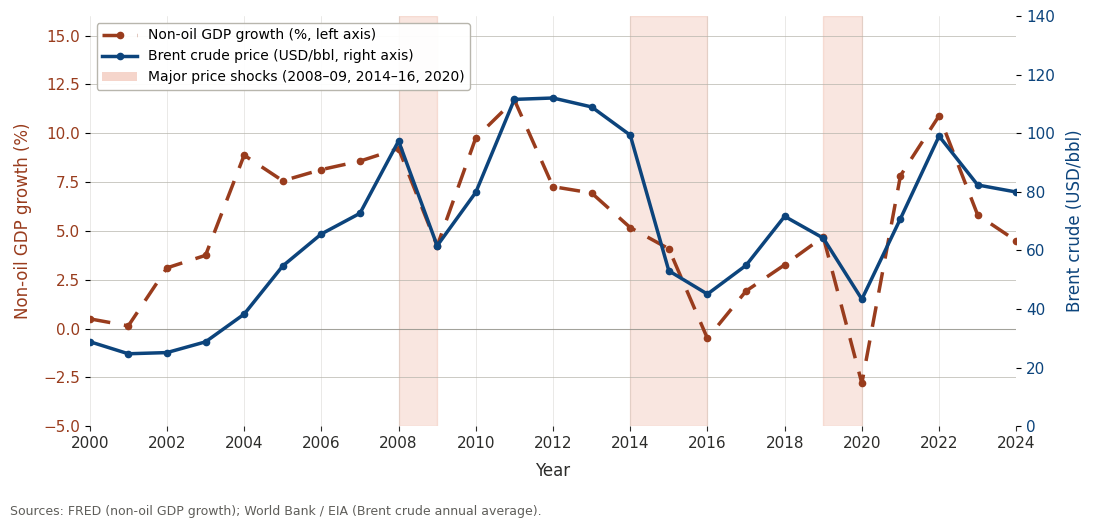

In [ ]:
df = pd.read_excel('Saudi_Arabia_merged_dataset.xlsx', sheet_name='Saudi_Model_Data')
df = df[['Year', 'Non-Oil Real GDP Growth (%)', 'Annual Avg Brent Price (USD/bbl)']].dropna()
df = df.sort_values('Year').reset_index(drop=True)

years   = df['Year'].astype(int).tolist()
non_oil = df['Non-Oil Real GDP Growth (%)'].tolist()
brent   = df['Annual Avg Brent Price (USD/bbl)'].tolist()

fig, ax1 = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('white')
ax1.set_facecolor('white')

for start, end in [(2008, 2009), (2014, 2016), (2019, 2020)]:
    ax1.axvspan(start, end, color='#D85A30', alpha=0.15, zorder=0)

ax1.set_xlabel('Year', fontsize=12, color='#2C2C2A', labelpad=8)
ax1.set_ylabel('Non-oil GDP growth (%)', fontsize=12, color='#993C1D', labelpad=8)
ax1.tick_params(axis='y', labelcolor='#993C1D', labelsize=11)
ax1.tick_params(axis='x', labelsize=11, colors='#2C2C2A')
ax1.set_ylim(-5, 16)
ax1.set_xlim(min(years), max(years))
ax1.set_xticks(range(min(years), max(years)+1, 2))
ax1.axhline(y=0, color='#888780', linewidth=0.8, linestyle='-', alpha=0.6, zorder=1)

line1, = ax1.plot(years, non_oil,
                  color='#993C1D', linewidth=2.5, linestyle='--', dashes=(6, 4),
                  marker='o', markersize=4.5, markerfacecolor='#993C1D',
                  markeredgecolor='#993C1D',
                  zorder=3, label='Non-oil GDP growth (%, left axis)')

ax2 = ax1.twinx()
ax2.set_ylabel('Brent crude (USD/bbl)', fontsize=12, color='#0C447C', labelpad=8)
ax2.tick_params(axis='y', labelcolor='#0C447C', labelsize=11)
ax2.set_ylim(0, 140)

line2, = ax2.plot(years, brent,
                  color='#0C447C', linewidth=2.5, linestyle='-',
                  marker='o', markersize=4.5, markerfacecolor='#0C447C',
                  markeredgecolor='#0C447C',
                  zorder=3, label='Brent crude price (USD/bbl, right axis)')

for spine in ax1.spines.values():
    spine.set_visible(False)
for spine in ax2.spines.values():
    spine.set_visible(False)

ax1.grid(axis='y', color='#B4B2A9', linewidth=0.6, alpha=0.8)
ax1.grid(axis='x', color='#B4B2A9', linewidth=0.4, alpha=0.5)
ax1.set_axisbelow(True)

shock_patch = mpatches.Patch(facecolor='#D85A30', alpha=0.25,
                              label='Major price shocks (2008–09, 2014–16, 2020)')
ax1.legend([line1, line2, shock_patch],
           [line1.get_label(), line2.get_label(), shock_patch.get_label()],
           loc='upper left', fontsize=10, frameon=True, framealpha=0.95,
           edgecolor='#B4B2A9', facecolor='white', handlelength=2.5)

fig.text(0.01, -0.04,
         'Sources: FRED (non-oil GDP growth); World Bank / EIA (Brent crude annual average).',
         fontsize=9, color='#5F5E5A', ha='left')

plt.tight_layout()
plt.savefig('saudi_oil_nonoil_chart.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
